In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib import pyplot as plt
import math
import pickle
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM
from sklearn.decomposition import PCA, IncrementalPCA
from scipy.stats import spearmanr
import torch.nn.functional as F
import torch
import os
from pathlib import Path
import joblib
from sklearn.pipeline import Pipeline

# Load relevant variables and functions

In [ ]:
CHARS = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
         "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
C2I_MAPPING = {c: i for i, c in enumerate(CHARS)}

def compute_log_conditional_probs(seq, tokenizer, model):
    """
    Given a single sequence, compute the log-probability
    of its true amino acid at each position i, conditioned
    on masking that position.
    Returns:
        logps: np.array of shape (L,) where L = len(seq)
    """
    L = len(seq)
    logps = np.zeros(L, dtype=np.float32)
    # add BOS/EOS tokens automatically
    for i in range(L):
        masked = list(seq)
        masked[i] = tokenizer.mask_token
        toks = tokenizer("".join(masked),
                         return_tensors="pt",
                         add_special_tokens=True,
                         truncation=True).to(device)
        with torch.no_grad():
            out = model(**toks).logits  # shape (1, T, V)
            # token index = i+1 (after BOS)
            token_idx = i + 1
            # get log‐softmax over vocab at that position
            log_probs = F.log_softmax(out[0, token_idx], dim=-1)
            true_id = tokenizer.convert_tokens_to_ids(seq[i])
            logps[i] = log_probs[true_id].item()
    return logps

def find_mut(wt_seq, query_seq):
    mut_list = []
    assert len(wt_seq) == len(query_seq)
    for i in range(len(wt_seq)):
        if wt_seq[i] != query_seq[i]:
            mut_list.append(wt_seq[i] + str(i+1) + query_seq[i])
    return mut_list

# Preprocess dataset into a df with sequence, mutations and fitness

In [ ]:
Dataset = 'Max_lrDMS' # 'Rike_high_confidence'|'Rike_low_confidence'|'Simon_ML'|'Simon_ML+Michal_neg'|'Max_lrDMS'

In [ ]:
neg_threshold = -5.0
root_dir = '/content/drive/MyDrive/Xai_ired/Data/'
work_dir = os.path.join(root_dir, Dataset)
os.makedirs(work_dir, exist_ok=True)
has_neg = False  # used for data spliting later

if Dataset.startswith('Rike'):
    if Dataset == 'Rike_high_confidence':
        input_file = os.path.join(root_dir, 'Rike_IRED_evolution_CHX_CPA_high confidence fitness scores.csv')
    else:
        input_file = os.path.join(root_dir, 'Rike_IRED_evolution_CHX_CPA_low confidence fitness scores.csv')
    df_data = pd.read_csv(input_file)
    wt_seq = df_data[df_data['mut_id']=='WT']['aa_seq'].tolist()[0]
    df = df_data[['aa_seq', 'mut_id', 'fitness_final']].rename(columns={'aa_seq': 'aa_seq', 'mut_id': 'mut', 'fitness_final': 'fitness'})
elif Dataset.startswith('Simon_ML'):
    input_file = os.path.join(root_dir, 'srired_michal.csv')
    df_data = pd.read_csv(input_file)
    wt_seq = df_data[df_data['aa_variant']=='WT']['aa_seq'].tolist()[0]
    df_simon = df_data[df_data['start_round'] > 0]
    df_michal = df_data[df_data['start_round'] == 0]
    # randomly sample negative dataset
    df_michal = df_michal.sample(n=1500, random_state=42)
    if Dataset == 'Simon_ML':
        df = df_simon
    else:
        df = pd.concat([df_simon, df_michal], ignore_index=True)
    df = df[['aa_seq', 'aa_variant', 'start_round', 'fitness_combined']].rename(columns={'aa_seq': 'aa_seq', 'aa_variant': 'mut',
                                                                                'start_round': 'start_round', 'fitness_combined': 'fitness'})
    df['mut'] = df['mut'].str.replace(',', '-', regex=False)

elif Dataset == 'Max_lrDMS':
    input_file = os.path.join(root_dir, '221111_CPA_merge_filtered.csv')
    df = pd.read_csv(input_file)
    wt_seq = df[df['WT']==True]['aa_seq'].tolist()[0]
    # drop rows with early stop
    df = df[df['STOP'] == False].reset_index(drop=True)
    # drop additional rows with early stop
    idx_drop = []
    for i in range(len(df)):
        if df.loc[i, 'aa_seq'][-1] != '*' or len(df.loc[i, 'aa_seq']) != len(wt_seq) or '*' in df.loc[i, 'aa_seq'][:-1]:
            idx_drop.append(i)
    df = df.drop(index=idx_drop).reset_index(drop=True)
    # drop variants with sigma >= 2.0
    # df = df[df['sigma'] < 2.0].reset_index(drop=True)
    # compute mutations
    muts = []
    for i in range(len(df)):
        if df.loc[i, 'WT'] == True:
            muts.append('WT')
        else:
            mut = find_mut(wt_seq, df.loc[i, 'aa_seq'])
            muts.append(('-').join(mut))
    df['mut'] = muts
    df = df[['aa_seq', 'mut', 'fitness']]

# remove stop codons from sequences
df['aa_seq'] = df['aa_seq'].str.rstrip('*')

num_total = len(df)
num_pos = len(df[df['fitness'] > neg_threshold])
print(f'Dataset: {Dataset}   total: {num_total} | pos: {num_pos}')
if num_pos < num_total:
    has_neg = True
df.to_csv(os.path.join(work_dir, 'data_processed.csv'), index=False)

Dataset: Max_lrDMS   total: 8589 | pos: 8589


# Generate AAindex embedding

In [ ]:
aaindex_ref = np.load('/content/drive/MyDrive/Mid_1_data/aaindex-pca-19.npy')
scaler = StandardScaler()
aaindex_ref = scaler.fit_transform(aaindex_ref)

# embed the WT
int_seq_wt = [C2I_MAPPING[wt_seq[j]] for j in range(len(wt_seq.rstrip('*')))]
int_seq_wt = np.array(int_seq_wt)
aaindex_wt = aaindex_ref[int_seq_wt] # L * 19

int_seqs = []
for i in tqdm(range(len(df))):
    seq = df.loc[i, 'aa_seq']
    int_seq = [C2I_MAPPING[seq[j]] for j in range(len(seq))]
    int_seqs.append(int_seq)
int_seqs = np.array(int_seqs)
# shape: N * L * 19
aaindex_emb = aaindex_ref[int_seqs]
# shape: N * (L*19)
aaindex_rr = aaindex_emb.reshape(aaindex_emb.shape[0], -1)
print(f'total AAindex embedding shape: {aaindex_rr.shape}')
# save flattened AAindex embedding
np.save(os.path.join(work_dir, 'AAindex_emb.npy'), aaindex_rr)

# save original AAindex embedding - WT embedding
aaindex_emb = aaindex_emb - aaindex_wt
zero_vec = np.zeros((aaindex_emb.shape[0], 1, aaindex_emb.shape[2]))
aaindex_emb = np.concatenate([zero_vec, aaindex_emb, zero_vec], axis=1)
print(f'total masked AAindex embedding shape: {aaindex_emb.shape}')
np.save(os.path.join(work_dir, 'AAindex_emb_masked.npy'), aaindex_emb)

  0%|          | 0/8589 [00:00<?, ?it/s]

total AAindex embedding shape: (8589, 5510)
total masked AAindex embedding shape: (8589, 292, 19)


# Generate ESM embeddings

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model     = AutoModel.from_pretrained(model_name).to(device)
model.eval()

seq_list = list(df['aa_seq'])
N = len(seq_list)
lengths = [len(s) for s in seq_list]
L_max = max(lengths)
hidden_dim = model.config.hidden_size

ESM_emb = np.zeros((N, L_max+2, hidden_dim), dtype=np.float32)
batch_size = 32
with torch.no_grad():
    for start in tqdm(range(0, N, batch_size)):
        batch_seqs = seq_list[start:start+batch_size]
        # Tokenize with padding up to the longest seq
        toks = tokenizer(
            batch_seqs,
            return_tensors="pt",
            padding="max_length",
            max_length=L_max+2,
            add_special_tokens=True,
            truncation=True
        )
        input_ids = toks["input_ids"].to(device)
        attention_mask = toks["attention_mask"].to(device)
        out = model(input_ids=input_ids, attention_mask=attention_mask)
        # last_hidden_state: (B, T, hidden_dim)
        last_hidden = out.last_hidden_state

        # For each sequence in batch, extract the residue embeddings
        # HuggingFace ESM2 prepends a BOS token and appends EOS token by default,
        # so token positions 1 .. (seq_len) correspond to protein residues.
        for i, seq in enumerate(batch_seqs):
            seq_len = len(seq)
            emb_residues = last_hidden[i, : seq_len + 2, :].cpu().numpy()
            ESM_emb[start + i, : seq_len + 2, :] = emb_residues

N, L_max, hidden_dim = ESM_emb.shape
# Flatten to (N * L_max, hidden_dim)
flat = ESM_emb.reshape(-1, hidden_dim)
scaler = StandardScaler()
flat_scaled = scaler.fit_transform(flat)
ESM_emb = flat_scaled.reshape(N, L_max, hidden_dim)
print(f'total ESM2 embedding shape: {ESM_emb.shape}')
np.save(os.path.join(work_dir, 'ESM_emb.npy'), ESM_emb)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 302c4a7c-03cb-45fa-9909-025e74a04daa)')' thrown while requesting HEAD https://huggingface.co/facebook/esm2_t33_650M_UR50D/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/269 [00:00<?, ?it/s]

total ESM2 embedding shape: (8589, 292, 1280)


# Generate Attention maps

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model = AutoModel.from_pretrained(model_name, output_attentions=True).to(device)
model.eval()

work_dir = os.path.join('/content/drive/MyDrive/Xai_ired/Data/', Dataset)
df = pd.read_csv(os.path.join(work_dir, 'data_processed.csv'))
seq_list = list(df['aa_seq'])
N = len(seq_list)
lengths = [len(s) for s in seq_list]
L_max = max(lengths)

# Store the average attention of the last 3 layers
# Shape: (N, L_max+2, L_max+2)
ESM_att = np.zeros((N, L_max+2, L_max+2), dtype=np.float32)
batch_size = 16 # Reduced batch size as attentions consume significant VRAM

with torch.no_grad():
    for start in tqdm(range(0, N, batch_size)):
        batch_seqs = seq_list[start:start+batch_size]
        toks = tokenizer(
            batch_seqs,
            return_tensors="pt",
            padding="max_length",
            max_length=L_max+2,
            add_special_tokens=True,
            truncation=True
        )
        input_ids = toks["input_ids"].to(device)
        attention_mask = toks["attention_mask"].to(device)

        out = model(input_ids=input_ids, attention_mask=attention_mask)

        # out.attentions is a tuple of 33 tensors
        # Each tensor shape: (Batch, Heads, L_max+2, L_max+2)
        # We select the last 3 layers: index 30, 31, 32
        last_layers = out.attentions[-3:]

        # 1. Stack layers: (3, Batch, Heads, L, L)
        # 2. Average across layers: (Batch, Heads, L, L)
        # 3. Average across heads: (Batch, L, L)
        combined_att = torch.stack(last_layers).mean(dim=0).mean(dim=1)

        # Move to CPU and store
        # We only care about the actual sequence length + special tokens
        ESM_att[start : start + len(batch_seqs)] = combined_att.cpu().numpy()

# Symmetrize: (A + A.T) / 2
ESM_att = (ESM_att + ESM_att.transpose(0, 2, 1)) / 2
# Save the attention maps
print(f'Total ESM2 Attention shape: {ESM_att.shape}')
np.save(os.path.join(work_dir, 'ESM_att.npy'), ESM_att)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 05e8b610-9b3f-4777-a5e7-14fac1d99d88)')' thrown while requesting HEAD https://huggingface.co/facebook/esm2_t33_650M_UR50D/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/537 [00:00<?, ?it/s]

Total ESM2 Attention shape: (8589, 292, 292)


# Peak the mutation signals in ESM embeddings

In [ ]:
work_dir = os.path.join('/content/drive/MyDrive/Xai_ired/Data/', Dataset)
df = pd.read_csv(os.path.join(work_dir, 'data_processed.csv'))
mut_list = df['mut'].str.split('-').tolist()
ESM_emb = np.load(os.path.join(work_dir, 'ESM_emb.npy'))
mask = np.zeros_like(ESM_emb)
wt_esm = np.zeros((ESM_emb.shape[1], ESM_emb.shape[2]))
for i, muts in tqdm(enumerate(mut_list)):
    if muts == ['WT']:
        wt_esm = ESM_emb[i]
        continue
    mut_indices = [int(mut[1:-1]) for mut in muts]
    for mut_idx in mut_indices:
        mask[i,mut_idx,:] = 1.0

wt_esm = np.expand_dims(wt_esm, axis=0)
ESM_emb_masked = (ESM_emb - wt_esm) * mask
np.save(os.path.join(work_dir, 'ESM_emb_masked.npy'), ESM_emb_masked)

0it [00:00, ?it/s]

In [ ]:
mut_list = df['mut'].str.split('-').tolist()
mask = np.zeros_like(ESM_emb)
for i, muts in tqdm(enumerate(mut_list)):
    mut_indices = [int(mut[1:-1]) for mut in muts]
    for mut_idx in mut_indices:
        mask[i,mut_idx,:] = 1.0

# ESM embed the wt_seq to obtain wt_esm
wt_esm = np.expand_dims(wt_esm, axis=0)
ESM_emb_masked = (ESM_emb - wt_esm) * mask
np.save(os.path.join(out_dir, 'ESM_emb_masked.npy'), ESM_emb_masked)

# PCA the ESM embeddings (Optional | not recommended)

In [ ]:
# Determine how many PCs do I need to capture 95% of the data variance


# ---- input & settings ----
EMB_PATH = "/content/drive/MyDrive/Xai_ired/Data/ESM_emb.npy"  # (N, L, D)
VAR_TARGET = 0.95
USE_INCREMENTAL = True          # set False to use standard PCA (needs more RAM)
CHUNK_ROWS = 50000              # tokens per chunk for IncrementalPCA
SAVE_PCA_NPZ = "/content/drive/MyDrive/Xai_ired/Data/ESM_pca_95.npz"  # optional

# ---- load & flatten to tokens ----
emb = np.load(EMB_PATH, mmap_mode="r")  # shape (N, L, D), right-padded with zeros
N, L, D = emb.shape
print(f"Embeddings: N={N}, L={L}, D={D}")

# Flatten to [T, D]; mask out padding rows (all zeros)
X = emb.reshape(-1, D)                  # [T, D]
valid_mask = ~(np.all(X == 0, axis=1))  # True for real tokens
X = X[valid_mask]
T = X.shape[0]
print(f"Valid tokens (non-padding): {T}")

# ---- PCA fit (choose incremental or full) ----
if not USE_INCREMENTAL:
    # Full PCA (centers data internally)
    pca = PCA(n_components=min(T-1, D), svd_solver="full")
    pca.fit(X)
    cum = np.cumsum(pca.explained_variance_ratio_)
else:
    # Memory-efficient pass to get cum-variance curve
    ipca = IncrementalPCA(n_components=min(D,  min(512, D)))  # temp cap
    for start in tqdm(range(0, T, CHUNK_ROWS), desc="IncrementalPCA - partial_fit"):
        ipca.partial_fit(X[start:start+CHUNK_ROWS])

    # After fitting, still need the explained variance ratios for all components.
    # IncrementalPCA gives ratios only for the selected n_components:
    # pick the smallest k within those that crosses 95%. If not crossed, refit with larger cap.
    cum = np.cumsum(ipca.explained_variance_ratio_)
    if cum[-1] < VAR_TARGET - 1e-6 and ipca.n_components_ < D:
        # Not enough components — refit once with a larger cap.
        new_n = min(D, max(ipca.n_components_ * 2, 1024))
        print(f"Expanding components to {new_n} to reach {VAR_TARGET*100:.1f}% variance.")
        ipca = IncrementalPCA(n_components=new_n)
        for start in tqdm(range(0, T, CHUNK_ROWS), desc="IncrementalPCA - partial_fit (expanded)"):
            ipca.partial_fit(X[start:start+CHUNK_ROWS])
        cum = np.cumsum(ipca.explained_variance_ratio_)
    pca = ipca

# ---- pick k for 95% ----
k95 = int(np.searchsorted(cum, VAR_TARGET) + 1)
print(f"#PCs to reach {VAR_TARGET*100:.1f}% variance: k = {k95}")
print(f"Cumulative variance at k: {cum[k95-1]:.4f}")

# ---- optionally save projection (components & mean) for reuse ----
if SAVE_PCA_NPZ:
    os.makedirs(os.path.dirname(SAVE_PCA_NPZ), exist_ok=True)
    comps = pca.components_[:k95]             # [k95, D]
    meanv = getattr(pca, "mean_", np.zeros(D, dtype=np.float64))  # [D]
    np.savez(SAVE_PCA_NPZ, components=comps, mean=meanv.astype(np.float32), k=k95, D=D)
    print(f"Saved PCA projection to: {SAVE_PCA_NPZ} (components[{comps.shape}], mean[{meanv.shape}])")

# ---- how to project later (example) ----
# X_centered = X - meanv
# X_pca = X_centered @ comps.T    # shape [T, k95]

In [ ]:
# Save the first 256 PCs of the ESM embedding
EMB_PATH = "/content/drive/MyDrive/Xai_ired/Data/ESM_emb.npy"      # (N, L, D)
OUT_PATH = "/content/drive/MyDrive/Xai_ired/Data/ESM_emb_256.npy"  # (N, L, 256)
N_COMPONENTS = 256
N_FIT_SEQ = 200                     # fit PCA on the first 200 sequences
RANDOM_STATE = 42
CHUNK_SEQS = 16                     # how many sequences to transform per chunk (tune for RAM)

# ---------- load (mmap to avoid copying big arrays) ----------
X = np.load(EMB_PATH, mmap_mode="r")  # shape (N, L, D)
N, L, D = X.shape
n_fit = min(N_FIT_SEQ, N)

print(f"[INFO] Loaded: {EMB_PATH} | shape={X.shape} | dtype={X.dtype}")
print(f"[INFO] Fitting PCA with first {n_fit} sequences => {(n_fit*L)} samples of dim {D}")

# ---------- fit PCA on the first 200 sequences ----------
X_fit = np.asarray(X[:n_fit]).reshape(-1, D)  # shape = (n_fit*L, D)
# randomized solver is fast & accurate for large D
pca = PCA(n_components=N_COMPONENTS, svd_solver="randomized", random_state=RANDOM_STATE)
pca.fit(X_fit)
joblib.dump(pca, "/content/drive/MyDrive/Xai_ired/Data/esm_pca.joblib")
print(f"[INFO] PCA explained variance ratio (first 5): {pca.explained_variance_ratio_[:5]}")

# ---------- prepare output (memmap to save space in RAM) ----------
out_shape = (N, L, N_COMPONENTS)
out_mm = np.lib.format.open_memmap(OUT_PATH, mode="w+", dtype=np.float32, shape=out_shape)
print(f"[INFO] Writing transformed embeddings to: {OUT_PATH} | shape={out_shape}")

# ---------- transform in chunks ----------
start = 0
while start < N:
    end = min(start + CHUNK_SEQS, N)
    # (batch, L, D) -> ((batch*L), D)
    X_chunk = np.asarray(X[start:end]).reshape(-1, D)
    # transform -> ((batch*L), 256) -> (batch, L, 256)
    Y_chunk = pca.transform(X_chunk).astype(np.float32).reshape(end - start, L, N_COMPONENTS)
    out_mm[start:end, :, :] = Y_chunk
    print(f"[INFO] Transformed sequences {start}:{end}")
    start = end

# Make sure data is flushed to disk
del out_mm

print(f"[DONE] Saved PCA embeddings -> {OUT_PATH}")

# Generate PLL

In [ ]:
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model     = AutoModelForMaskedLM.from_pretrained(model_name).to(device)
model.eval()

# Compute conditional log likelihoods for reference sequence
P_wt = compute_log_conditional_probs(wt_seq, tokenizer, model)

# For each sequence, compute PLL
PLL = np.zeros((len(df), 1), dtype=np.float32)

for idx, seq in tqdm(enumerate(list(df['aa_seq']))):

    if df.loc[idx, 'mut'] == 'WT':
        PLL[idx, 0] = 0.0
        continue
    # find mutated positions
    muts = [int(x[1:-1])-1 for x in df.loc[idx, 'mut'].split('-')]
    # compute log‐probs for each mutated position
    logp_mut = 0.0
    for i in muts:
        masked = list(seq)
        masked[i] = tokenizer.mask_token
        toks = tokenizer("".join(masked),
                        return_tensors="pt",
                        add_special_tokens=True,
                        truncation=True).to(device)
        with torch.no_grad():
            out = model(**toks).logits
            log_probs = F.log_softmax(out[0, i+1], dim=-1)
            true_id = tokenizer.convert_tokens_to_ids(seq[i])
            logp_mut += log_probs[true_id].item()
    # PLL = sum logp_mutated – sum P_wt at those positions
    PLL[idx, 0] = logp_mut - P_wt[muts].sum()

print(f'total PLL shape: {PLL.shape}')
np.save(os.path.join(work_dir, 'PLL.npy'), PLL)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


0it [00:00, ?it/s]

total PLL shape: (8589, 1)


# Plot the correlation between PLL and fitness

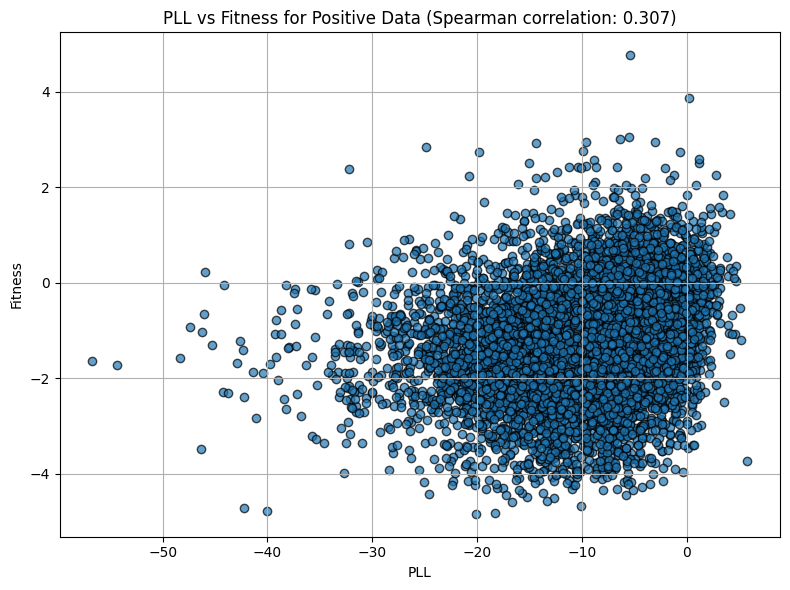

In [ ]:
pll = np.load(os.path.join(work_dir, 'PLL.npy'))
pos_idx = np.where(df['fitness']>neg_threshold)[0]
corr, _ = spearmanr(pll[pos_idx], df['fitness'][pos_idx])

plt.figure(figsize=(8, 6))
plt.scatter(pll[pos_idx], df['fitness'][pos_idx], alpha=0.7, edgecolors='k')
plt.title(f'PLL vs Fitness for Positive Data (Spearman correlation: {corr:.3f})')
plt.xlabel('PLL')
plt.ylabel('Fitness')
plt.grid(True)
plt.tight_layout()
plt.show()

# Split positive and negative data for training/validation

In [ ]:
# -----------------------
# Helpers
# -----------------------
SEED = 42
rng = np.random.default_rng(SEED)

def make_folds(df_in, n_folds=5, rng=None):
    """Return a list of n_folds lists of original row indices (shuffled)."""
    idx = df_in.index.to_numpy()
    idx = idx.copy()
    rng.shuffle(idx)
    folds = np.array_split(idx, n_folds)
    return [fold.tolist() for fold in folds]

def subsample_each_fold(folds, k, rng=None):
    """Subsample up to k indices from each fold (without replacement)."""
    out = []
    for f in folds:
        if len(f) <= k:
            out.append(f)
        else:
            out.append(rng.choice(f, size=k, replace=False).tolist())
    return out

def save_indices_and_labels(path, k, idx_list, df):
    """Save indices_{k}.pkl and labels_{k}.pkl (labels match indices order)."""
    path.mkdir(parents=True, exist_ok=True)
    with open(path / f"indices_{k}.pkl", "wb") as f:
        pickle.dump(idx_list, f)
    print(f'saving {path} fold {k}.........')
    labels = [float(x) for x in list(df.loc[idx_list, 'fitness'])]
    with open(path / f"labels_{k}.pkl", "wb") as f:
        pickle.dump(labels, f)
    print(f'length of idx_list: {len(idx_list)}')
    print(f'length of labels: {len(labels)}')

In [ ]:
# -----------------------
# Config
# -----------------------
CSV_PATH    = os.path.join(work_dir, 'data_processed.csv')
OUT_TRAIN   = Path(os.path.join(work_dir, 'train'))
OUT_TEST    = Path(os.path.join(work_dir, 'test'))

N_FOLDS = 5
if has_neg:
    NEG_SUBSAMPLE = 340  # per fold

# -----------------------
# Load + filtering
# -----------------------
df = pd.read_csv(CSV_PATH)
print(f'length of df: {len(df)}')

if has_neg:
    df_pos = df[df['fitness'] > neg_threshold]
    df_neg = df[df['fitness'] <= neg_threshold]

    pos_folds = make_folds(df_pos, n_folds=N_FOLDS, rng=rng)
    neg_folds = make_folds(df_neg, n_folds=N_FOLDS, rng=rng)

    # Subsample from each neg fold
    neg_folds = subsample_each_fold(neg_folds, NEG_SUBSAMPLE, rng=rng)

    # expose variables pos_fold_0 ... pos_fold_4 etc.
    pos_fold_0, pos_fold_1, pos_fold_2, pos_fold_3, pos_fold_4 = pos_folds
    neg_fold_0, neg_fold_1, neg_fold_2, neg_fold_3, neg_fold_4 = neg_folds
    print('--------------fold size stats----------------------')
    print(f'pos_fold: {len(pos_fold_0)} | {len(pos_fold_1)} | {len(pos_fold_2)} | {len(pos_fold_3)} | {len(pos_fold_4)} | total: {len(df_pos)}')
    print(f'neg_fold: {len(neg_fold_0)} | {len(neg_fold_1)} | {len(neg_fold_2)} | {len(neg_fold_3)} | {len(neg_fold_4)} | total: {len(df_neg)}')

    # -----------------------
    # Write train and test splits
    # -----------------------

    for k in range(N_FOLDS):
        # --- train: (pos except k) + (neg except k)
        train_idx = (
            [i for j, fold in enumerate(pos_folds) if j != k for i in fold] +
            [i for j, fold in enumerate(neg_folds) if j != k for i in fold]
        )
        rng.shuffle(train_idx)
        save_indices_and_labels(OUT_TRAIN, k, train_idx, df)

        # --- test: pos_fold_k + neg_fold_k
        test_idx = pos_folds[k] + neg_folds[k]
        rng.shuffle(test_idx)
        save_indices_and_labels(OUT_TEST, k, test_idx, df)

else:
    folds = make_folds(df, n_folds=N_FOLDS, rng=rng)

    # expose variables pos_fold_0 ... pos_fold_4 etc.
    fold_0, fold_1, fold_2, fold_3, fold_4 = folds
    print('--------------fold size stats----------------------')
    print(f'pos_fold: {len(fold_0)} | {len(fold_1)} | {len(fold_2)} | {len(fold_3)} | {len(fold_4)} | total: {len(df)}')

    # -----------------------
    # Write train and test splits
    # -----------------------

    for k in range(N_FOLDS):
        # --- train: fold except k
        train_idx = [i for j, fold in enumerate(folds) if j != k for i in fold]
        rng.shuffle(train_idx)
        save_indices_and_labels(OUT_TRAIN, k, train_idx, df)

        # --- test: fold k
        test_idx = folds[k]
        rng.shuffle(test_idx)
        save_indices_and_labels(OUT_TEST, k, test_idx, df)


length of df: 8589
--------------fold size stats----------------------
pos_fold: 1718 | 1718 | 1718 | 1718 | 1717 | total: 8589
saving /content/drive/MyDrive/Xai_ired/Data/Max_lrDMS/train fold 0.........
length of idx_list: 6871
length of labels: 6871
saving /content/drive/MyDrive/Xai_ired/Data/Max_lrDMS/test fold 0.........
length of idx_list: 1718
length of labels: 1718
saving /content/drive/MyDrive/Xai_ired/Data/Max_lrDMS/train fold 1.........
length of idx_list: 6871
length of labels: 6871
saving /content/drive/MyDrive/Xai_ired/Data/Max_lrDMS/test fold 1.........
length of idx_list: 1718
length of labels: 1718
saving /content/drive/MyDrive/Xai_ired/Data/Max_lrDMS/train fold 2.........
length of idx_list: 6871
length of labels: 6871
saving /content/drive/MyDrive/Xai_ired/Data/Max_lrDMS/test fold 2.........
length of idx_list: 1718
length of labels: 1718
saving /content/drive/MyDrive/Xai_ired/Data/Max_lrDMS/train fold 3.........
length of idx_list: 6871
length of labels: 6871
saving 

# Embed the evaluation sets

In [ ]:
# Read in and process respective evaluation set
Dataset = 'Max_lrDMS' # 'Rike_high_confidence'|'Rike_low_confidence'|'Simon_ML'|'Simon_ML+Michal_neg'|'Max_lrDMS'

work_dir = os.path.join('/content/drive/MyDrive/Xai_ired/Data/', Dataset)
eval_dir = os.path.join(work_dir, 'evaluation')
df_ref = pd.read_csv(os.path.join(work_dir, 'data_processed.csv'))
wt_seq = df_ref[df_ref['mut'] == 'WT']['aa_seq'].tolist()[0].rstrip('*')
wt_idx = df_ref.index[df_ref['mut'].eq('WT')][0]
print(f'WT at row {wt_idx} in the reference dataset')

df = pd.read_excel(os.path.join(work_dir, 'plate_dataset.xlsx'))
df['aa_seq'] = df['aa_seq'].str.rstrip('*')
idx_drop = []
for i in range(len(df)):
    if len(df.loc[i, 'aa_seq']) != len(wt_seq):
        idx_drop.append(i)
    else:
        temp_seq = df.loc[i, 'aa_seq']
        for j in range(len(temp_seq)):
            if temp_seq[j] not in C2I_MAPPING:
                idx_drop.append(i)
                break

df = df.drop(index=idx_drop).reset_index(drop=True)
print(f'{len(df)} samples in the evaluation dataset')
# compute mutations
muts = []
for i in range(len(df)):
    mut = find_mut(wt_seq, df.loc[i, 'aa_seq'])
    if mut:
        muts.append(('-').join(mut))
    else:
        muts.append('WT')
df['mut'] = muts
os.makedirs(eval_dir, exist_ok=True)
df.to_csv(os.path.join(work_dir, 'plate_dataset.csv'), index=False)

WT at row 2 in the reference dataset
52 samples in the evaluation dataset


In [ ]:
# Generate AAindex embeddings
df = pd.read_csv(os.path.join(work_dir, 'plate_dataset.csv'))
aaindex_ref = np.load('/content/drive/MyDrive/Mid_1_data/aaindex-pca-19.npy')
scaler = StandardScaler()
aaindex_ref = scaler.fit_transform(aaindex_ref)

# embed the WT
int_seq_wt = [C2I_MAPPING[wt_seq[j]] for j in range(len(wt_seq.rstrip('*')))]
int_seq_wt = np.array(int_seq_wt)
aaindex_wt = aaindex_ref[int_seq_wt] # L * 19

# generate AAindex embeddings
int_seqs = []
for i in tqdm(range(len(df))):
    seq = df.loc[i, 'aa_seq']
    int_seq = [C2I_MAPPING[seq[j]] for j in range(len(seq))]
    int_seqs.append(int_seq)
int_seqs = np.array(int_seqs)
# shape: N * L * 19
aaindex_emb = aaindex_ref[int_seqs]
# shape: N * (L*19)
aaindex_rr = aaindex_emb.reshape(aaindex_emb.shape[0], -1)
print(f'total AAindex embedding shape: {aaindex_rr.shape}')
np.save(os.path.join(eval_dir, 'AAindex_emb.npy'), aaindex_rr)

# save original AAindex embedding - WT embedding
aaindex_emb = aaindex_emb - aaindex_wt
zero_vec = np.zeros((aaindex_emb.shape[0], 1, aaindex_emb.shape[2]))
aaindex_emb = np.concatenate([zero_vec, aaindex_emb, zero_vec], axis=1)
print(f'total masked AAindex embedding shape: {aaindex_emb.shape}')
np.save(os.path.join(eval_dir, 'AAindex_emb_masked.npy'), aaindex_emb)

  0%|          | 0/52 [00:00<?, ?it/s]

total AAindex embedding shape: (52, 5510)
total masked AAindex embedding shape: (52, 292, 19)


In [ ]:
# Generate PLLs

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model     = AutoModelForMaskedLM.from_pretrained(model_name).to(device)
model.eval()

# Compute conditional log likelihoods for reference sequence
P_wt = compute_log_conditional_probs(wt_seq, tokenizer, model)

# For each sequence, compute PLL
PLL = np.zeros((len(df), 1), dtype=np.float32)

for idx, seq in tqdm(enumerate(list(df['aa_seq']))):

    if df.loc[idx, 'mut'] == 'WT':
        PLL[idx, 0] = 0.0
        continue
    # find mutated positions
    muts = [int(x[1:-1])-1 for x in df.loc[idx, 'mut'].split('-')]
    # compute log‐probs for each mutated position
    logp_mut = 0.0
    for i in muts:
        masked = list(seq)
        masked[i] = tokenizer.mask_token
        toks = tokenizer("".join(masked),
                        return_tensors="pt",
                        add_special_tokens=True,
                        truncation=True).to(device)
        with torch.no_grad():
            out = model(**toks).logits
            log_probs = F.log_softmax(out[0, i+1], dim=-1)
            true_id = tokenizer.convert_tokens_to_ids(seq[i])
            logp_mut += log_probs[true_id].item()
    # PLL = sum logp_mutated – sum P_wt at those positions
    PLL[idx, 0] = logp_mut - P_wt[muts].sum()

print(f'total PLL shape: {PLL.shape}')
np.save(os.path.join(eval_dir, 'PLL.npy'), PLL)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


0it [00:00, ?it/s]

total PLL shape: (52, 1)


In [ ]:
# Generate ESM embeddings

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model     = AutoModel.from_pretrained(model_name).to(device)
model.eval()

seq_list = list(df['aa_seq'])
N = len(seq_list)
lengths = [len(s) for s in seq_list]
L_max = max(lengths)
hidden_dim = model.config.hidden_size

ESM_emb = np.zeros((N, L_max+2, hidden_dim), dtype=np.float32)
batch_size = 32
with torch.no_grad():
    for start in tqdm(range(0, N, batch_size)):
        batch_seqs = seq_list[start:start+batch_size]
        # Tokenize with padding up to the longest seq
        toks = tokenizer(
            batch_seqs,
            return_tensors="pt",
            padding="max_length",
            max_length=L_max+2,
            add_special_tokens=True,
            truncation=True
        )
        input_ids = toks["input_ids"].to(device)
        attention_mask = toks["attention_mask"].to(device)
        out = model(input_ids=input_ids, attention_mask=attention_mask)
        # last_hidden_state: (B, T, hidden_dim)
        last_hidden = out.last_hidden_state

        # For each sequence in batch, extract the residue embeddings
        # HuggingFace ESM2 prepends a BOS token and appends EOS token by default,
        # so token positions 1 .. (seq_len) correspond to protein residues.
        for i, seq in enumerate(batch_seqs):
            seq_len = len(seq)
            emb_residues = last_hidden[i, : seq_len + 2, :].cpu().numpy()
            ESM_emb[start + i, : seq_len + 2, :] = emb_residues

N, L_max, hidden_dim = ESM_emb.shape
# Flatten to (N * L_max, hidden_dim)
flat = ESM_emb.reshape(-1, hidden_dim)
scaler = StandardScaler()
flat_scaled = scaler.fit_transform(flat)
ESM_emb = flat_scaled.reshape(N, L_max, hidden_dim)
print(f'total ESM2 embedding shape: {ESM_emb.shape}')
np.save(os.path.join(eval_dir, 'ESM_emb.npy'), ESM_emb)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/2 [00:00<?, ?it/s]

total ESM2 embedding shape: (52, 292, 1280)


In [ ]:
# Peak the ESM mutation signals
wt_esm = np.load(os.path.join(work_dir, 'ESM_emb.npy'))
wt_esm = wt_esm[wt_idx]

mut_list = df['mut'].str.split('-').tolist()
ESM_emb = np.load(os.path.join(eval_dir, 'ESM_emb.npy'))
mask = np.zeros_like(ESM_emb)
for i, muts in tqdm(enumerate(mut_list)):
    if muts == ['WT']:
        continue
    mut_indices = [int(mut[1:-1]) for mut in muts]
    for mut_idx in mut_indices:
        mask[i,mut_idx,:] = 1.0

wt_esm = np.expand_dims(wt_esm, axis=0)
ESM_emb_masked = (ESM_emb - wt_esm) * mask
np.save(os.path.join(eval_dir, 'ESM_emb_masked.npy'), ESM_emb_masked)

0it [00:00, ?it/s]

In [ ]:
# Generate the attention maps

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model = AutoModel.from_pretrained(model_name, output_attentions=True).to(device)
model.eval()

seq_list = list(df['aa_seq'])
N = len(seq_list)
lengths = [len(s) for s in seq_list]
L_max = max(lengths)

# Store the average attention of the last 3 layers
# Shape: (N, L_max+2, L_max+2)
ESM_att = np.zeros((N, L_max+2, L_max+2), dtype=np.float32)
batch_size = 16 # Reduced batch size as attentions consume significant VRAM

with torch.no_grad():
    for start in tqdm(range(0, N, batch_size)):
        batch_seqs = seq_list[start:start+batch_size]
        toks = tokenizer(
            batch_seqs,
            return_tensors="pt",
            padding="max_length",
            max_length=L_max+2,
            add_special_tokens=True,
            truncation=True
        )
        input_ids = toks["input_ids"].to(device)
        attention_mask = toks["attention_mask"].to(device)

        out = model(input_ids=input_ids, attention_mask=attention_mask)

        # out.attentions is a tuple of 33 tensors
        # Each tensor shape: (Batch, Heads, L_max+2, L_max+2)
        # We select the last 3 layers: index 30, 31, 32
        last_layers = out.attentions[-3:]

        # 1. Stack layers: (3, Batch, Heads, L, L)
        # 2. Average across layers: (Batch, Heads, L, L)
        # 3. Average across heads: (Batch, L, L)
        combined_att = torch.stack(last_layers).mean(dim=0).mean(dim=1)

        # Move to CPU and store
        # We only care about the actual sequence length + special tokens
        ESM_att[start : start + len(batch_seqs)] = combined_att.cpu().numpy()

# Symmetrize: (A + A.T) / 2
ESM_att = (ESM_att + ESM_att.transpose(0, 2, 1)) / 2
# Save the attention maps
print(f'Total ESM2 Attention shape: {ESM_att.shape}')
np.save(os.path.join(eval_dir, 'ESM_att.npy'), ESM_att)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/4 [00:00<?, ?it/s]

Total ESM2 Attention shape: (52, 292, 292)
